# Task 3 — Distributions and Relationships: Penguins

This notebook analyzes 344 penguins from three species and three islands.

## Lecture chart rules followed

- Every chart title states a **finding**, not merely the axis variables.
- Bars start at zero.
- No chart uses two y-axes.
- Colour is used only when it communicates a meaningful grouping.
- Labels are selective rather than attached to every point.
- Every chart states how missing rows were handled.

### Missing-value decision

The dataset contains:
- **2 penguins missing all four measurements** (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, and `body_mass_g`).
- **11 penguins missing `sex`**.

I will **not delete all 11 sex-missing penguins from the entire analysis**, because `sex` is not needed for the first three tasks.

Instead:
- Charts 1–3 use the 342 penguins with the required measurement(s) present, so **2 rows are excluded**.
- Chart 4 requires both `body_mass_g` and `sex`, so **11 rows are excluded**.
- No values are imputed.


## 1. Load and inspect the data


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("penguins.csv")

print("Shape:", df.shape)
print("Columns:", list(df.columns))
display(df.head())

assert df.shape == (344, 7)
assert df[[
    "species", "island", "bill_length_mm", "bill_depth_mm",
    "flipper_length_mm", "body_mass_g", "sex"
]].shape == (344, 7)


Shape: (344, 7)
Columns: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [2]:
measurement_cols = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

missing_summary = df.isna().sum().to_frame("Missing values")
display(missing_summary)

all_measurements_missing = df[measurement_cols].isna().all(axis=1)

print("Rows with all four measurements missing:", all_measurements_missing.sum())
print("Rows with missing sex:", df["sex"].isna().sum())
print("Rows with complete measurements:", df[measurement_cols].notna().all(axis=1).sum())
print("Rows with complete body mass + sex:", (df["body_mass_g"].notna() & df["sex"].notna()).sum())

display(df.loc[all_measurements_missing])


,Missing values
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


Rows with all four measurements missing: 2
Rows with missing sex: 11
Rows with complete measurements: 342
Rows with complete body mass + sex: 333


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


## 2. Decide how to handle the missing values

The two rows missing all four measurements cannot contribute to the measurement-based charts, so they are excluded from Charts 1–3.

The 11 rows missing `sex` are retained for Charts 1–3 because those charts do not use sex. They are excluded from Chart 4 because a species-by-sex comparison requires a known sex.

This is preferable to dropping all incomplete rows at the beginning, because doing so would unnecessarily remove usable information.


## 3. Chart 1 — Distribution of body mass

A **histogram** is appropriate because the question asks about the distribution and its shape. A histogram groups a continuous measurement into intervals, allowing us to see whether the data form one hump, several humps, or another shape.

No colour is needed because there is no grouping in this first view.


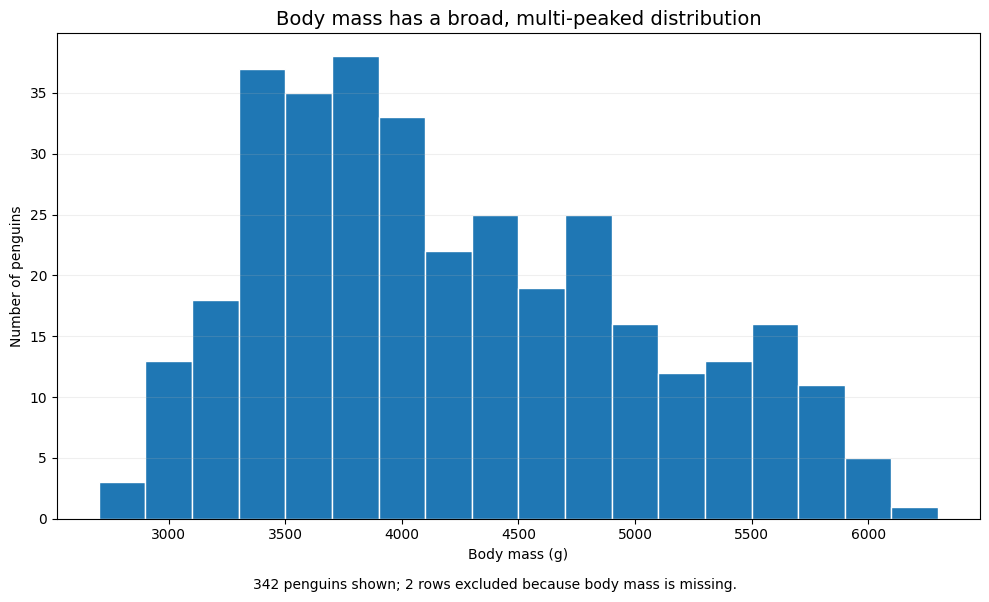

In [3]:
body_mass = df.loc[df["body_mass_g"].notna(), "body_mass_g"]

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    body_mass,
    bins=18,
    edgecolor="white"
)

ax.set_title(
    "Body mass has a broad, multi-peaked distribution",
    fontsize=14
)
ax.set_xlabel("Body mass (g)")
ax.set_ylabel("Number of penguins")
ax.grid(axis="y", alpha=0.2)

fig.text(
    0.5, 0.01,
    "342 penguins shown; 2 rows excluded because body mass is missing.",
    ha="center",
    fontsize=10
)

fig.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()


### Why this chart type?

A histogram is the most direct choice for a distribution because it shows how observations are spread across ranges of body mass. It makes the number and approximate location of peaks visible, which is exactly what the question asks.

### What we see

The overall body-mass distribution is not simply one clean hump. It has multiple peaks / shoulders, suggesting that different groups of penguins may be mixed together. The next chart checks whether species explains that structure.


## 4. Chart 2 — Body-mass distribution split by species

Use three small histograms with identical x-axis limits and binning. Small multiples make the distributions directly comparable without forcing all species into one overlapping plot.

Colour is removed because the species identity is already given by the panel titles; adding colour would not add information.


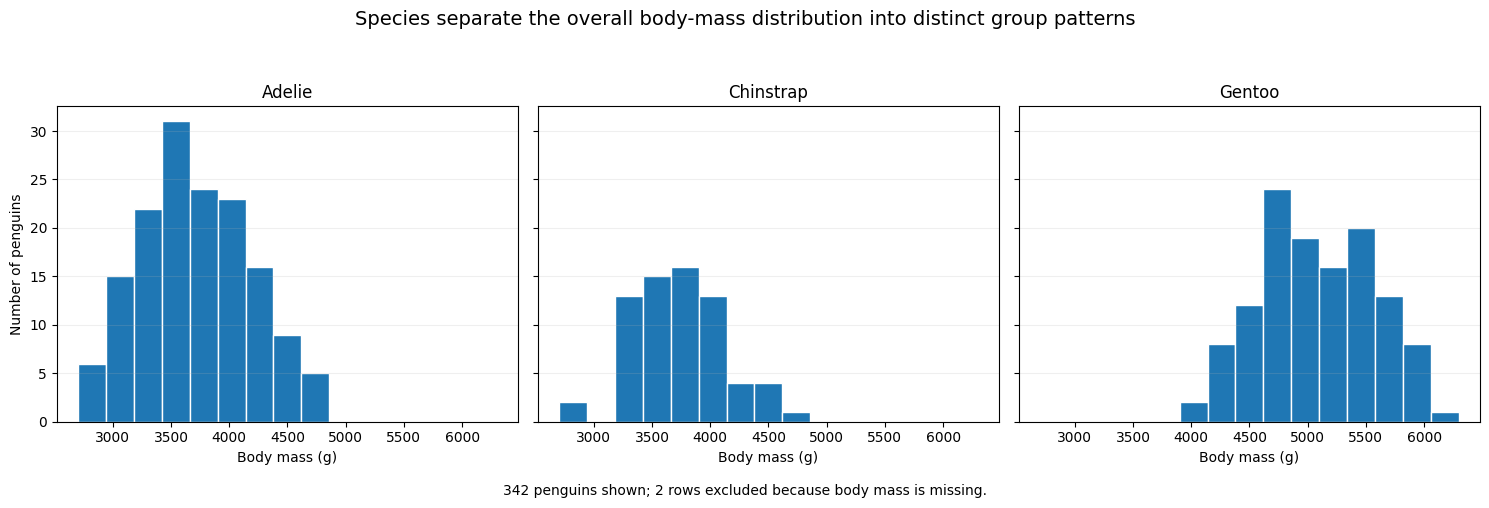

In [4]:
species_order = ["Adelie", "Chinstrap", "Gentoo"]
bins = np.linspace(
    df["body_mass_g"].min(),
    df["body_mass_g"].max(),
    16
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, species in zip(axes, species_order):
    values = df.loc[
        (df["species"] == species) & df["body_mass_g"].notna(),
        "body_mass_g"
    ]

    ax.hist(values, bins=bins, edgecolor="white")
    ax.set_title(species)
    ax.set_xlabel("Body mass (g)")
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("Number of penguins")

fig.suptitle(
    "Species separate the overall body-mass distribution into distinct group patterns",
    fontsize=14
)
fig.text(
    0.5, 0.01,
    "342 penguins shown; 2 rows excluded because body mass is missing.",
    ha="center",
    fontsize=10
)

fig.tight_layout(rect=[0, 0.04, 1, 0.93])
plt.show()


### Why this chart type?

Small-multiple histograms are useful here because the goal is to compare the **shape of a distribution across species**. Keeping the same bins and shared scale makes the differences in location and spread easy to compare.

### What we see

The apparent multi-peaked shape in the overall histogram is largely explained by mixing species with different body-mass distributions. Gentoo penguins are generally much heavier, while Adelie and Chinstrap occupy lower ranges with their own distributions.


## 5. Chart 3 — Bill length versus bill depth

A **scatter plot** is appropriate because both variables are quantitative and we want to examine their relationship.

Species is mapped to colour because species is the grouping variable that explains the apparent reversal in the relationship. The same axes are used for all species so the within-group patterns can be compared directly.


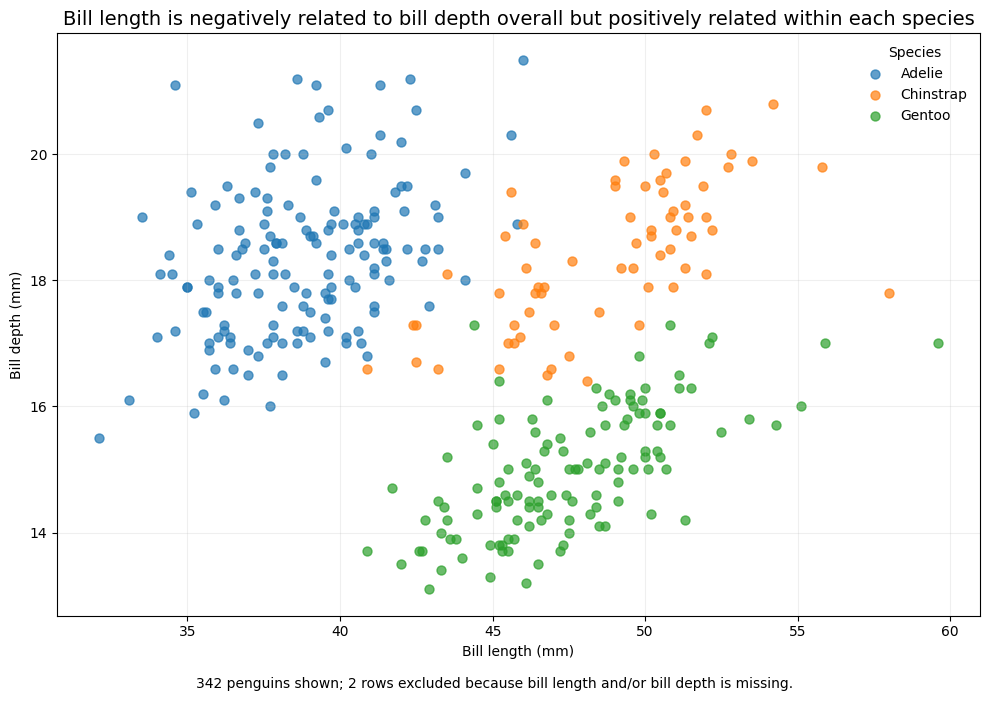

In [5]:
scatter_df = df[
    df["bill_length_mm"].notna() &
    df["bill_depth_mm"].notna()
].copy()

fig, ax = plt.subplots(figsize=(10, 7))

for species in species_order:
    subset = scatter_df[scatter_df["species"] == species]
    ax.scatter(
        subset["bill_length_mm"],
        subset["bill_depth_mm"],
        s=42,
        alpha=0.7,
        label=species
    )

ax.set_title(
    "Bill length is negatively related to bill depth overall but positively related within each species",
    fontsize=14
)
ax.set_xlabel("Bill length (mm)")
ax.set_ylabel("Bill depth (mm)")
ax.grid(alpha=0.2)
ax.legend(title="Species", frameon=False)

fig.text(
    0.5, 0.01,
    "342 penguins shown; 2 rows excluded because bill length and/or bill depth is missing.",
    ha="center",
    fontsize=10
)

fig.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()


### Why this chart type?

A scatter plot is the natural choice for two continuous measurements because it shows the direction, strength, and shape of their relationship. Colouring by species is essential here because the task specifically asks us to compare the overall relationship with the relationships **within species**.

### What is happening?

Across all 342 penguins with both measurements, the correlation is approximately **−0.24**. But within each species it becomes positive:

- Adelie: **+0.39**
- Chinstrap: **+0.65**
- Gentoo: **+0.64**

The negative overall relationship is therefore produced largely by differences **between species**. The species occupy different regions of the plot, and those between-species differences overwhelm the positive relationships that exist inside each species.

This is an example of **Simpson's paradox**: the direction of an association can change when a third variable is taken into account and the data are analyzed separately by that variable. citeturn0search12turn0search0

The important lesson is that the aggregate relationship can be misleading when groups have different distributions. Plotting the groups separately reveals the within-species relationships.


## 6. Verify the relationship numerically

The correlations below are not a replacement for the scatterplot; they are a compact numerical check of what the plot shows.


In [6]:
overall_corr = scatter_df["bill_length_mm"].corr(scatter_df["bill_depth_mm"])

within_species_corr = (
    scatter_df.groupby("species")
    .apply(
        lambda g: g["bill_length_mm"].corr(g["bill_depth_mm"]),
        include_groups=False
    )
    .rename("Correlation")
)

print(f"Overall correlation: {overall_corr:.3f}")
display(within_species_corr.to_frame().round(3))


Overall correlation: -0.235


,Correlation
species,
Adelie,0.391
Chinstrap,0.654
Gentoo,0.643


## 7. Chart 4 — Average body mass by species and sex

A **grouped bar chart** is appropriate because the question asks us to compare averages across categorical groups: species and sex.

The bars start at zero, as required by the lecture rules. Colour represents **sex**, so the colour has a meaningful grouping role. Only the bar values are selectively labeled where useful.

Because 11 penguins have missing sex, they are excluded from this chart.


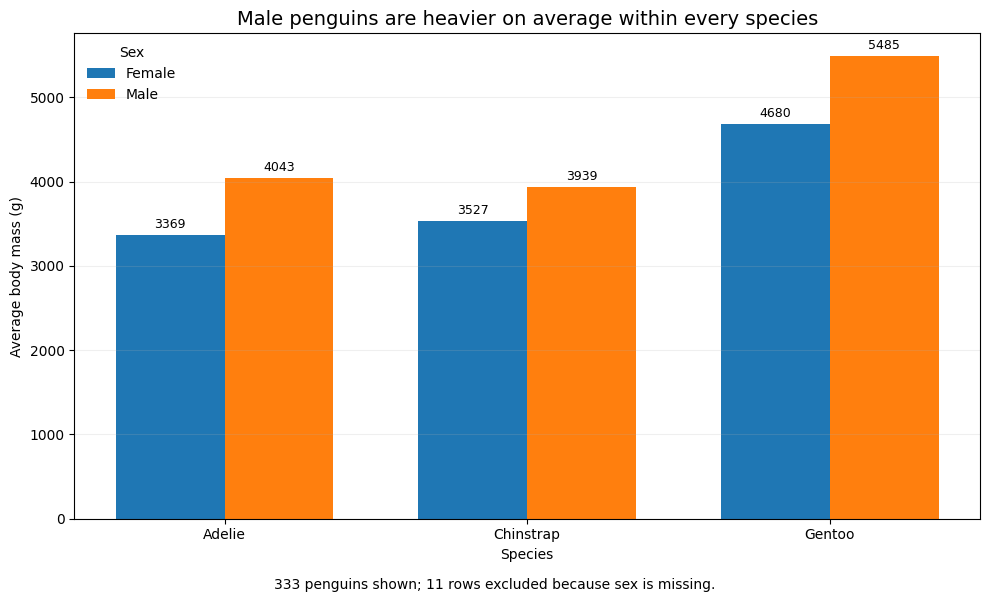

In [7]:
mass_sex = df.dropna(subset=["body_mass_g", "sex"]).copy()

mean_mass = (
    mass_sex
    .groupby(["species", "sex"], as_index=False)["body_mass_g"]
    .mean()
)

sex_order = ["FEMALE", "MALE"]
x = np.arange(len(species_order))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 6))

for i, sex in enumerate(sex_order):
    values = (
        mean_mass[mean_mass["sex"] == sex]
        .set_index("species")
        .reindex(species_order)["body_mass_g"]
        .values
    )

    bars = ax.bar(
        x + (i - 0.5) * width,
        values,
        width,
        label=sex.title()
    )

    # Selective labels: label each group average because the chart compares exact averages.
    ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=9)

ax.set_title(
    "Male penguins are heavier on average within every species",
    fontsize=14
)
ax.set_xlabel("Species")
ax.set_ylabel("Average body mass (g)")
ax.set_xticks(x)
ax.set_xticklabels(species_order)
ax.grid(axis="y", alpha=0.2)
ax.legend(title="Sex", frameon=False)

fig.text(
    0.5, 0.01,
    "333 penguins shown; 11 rows excluded because sex is missing.",
    ha="center",
    fontsize=10
)

fig.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()


### Why this chart type?

A grouped bar chart works well because the quantities being compared are **means for discrete groups**. Placing female and male bars next to each other within each species makes both dimensions of the comparison visible at once.

Colour is meaningful here because it identifies sex. A bar chart also makes the differences in average body mass easy to compare across the categorical groups.

### What we see

Within each of the three species, the male average body mass is higher than the female average. The absolute size of the difference varies by species, and Gentoo has the highest average body mass for both sexes.


## 8. Overall conclusion

The four charts tell a connected story:

1. The overall body-mass distribution has multiple peaks rather than one simple hump.
2. Splitting by species explains much of that shape because the species have different body-mass distributions.
3. The bill-length/bill-depth relationship is the most important example: the overall correlation is negative, while the within-species correlations are positive. This reversal is an example of **Simpson's paradox** and shows why subgroup structure matters.
4. Average body mass differs by both species and sex, with males heavier on average within each species.

The missing-value decision is also important: we did not discard every row with any missing value. We excluded only the observations that lacked the measurements required for a particular chart. This preserves usable information while making the exclusions explicit.
